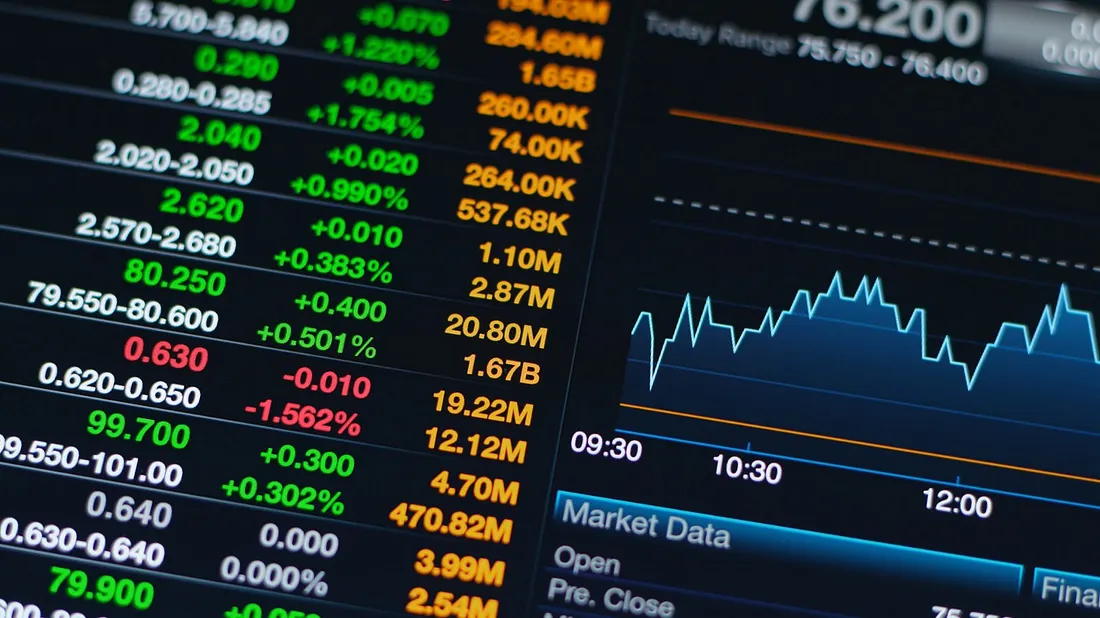

**Introduction:**

Pour prévoir le prix futur d’une action, il est essentiel d’analyser l’évolution de ses cours. Cela commence par la représentation graphique des tendances de variation des prix. Les méthodes utilisées pour interpréter ces graphiques afin d’anticiper l’évolution du marché sont regroupées sous le terme analyse technique.

Créé en 1987, le CAC 40 est le principal indice boursier de Paris. Sa première cotation a été fixée au 31 décembre 1987, mais il est officiellement entré en vigueur le 15 juin 1988. Pour notre analyse, nous avons choisi de travailler avec les tickers des sociétés composant le CAC 40. Un ticker est un code unique attribué à chaque action cotée en bourse, permettant de l’identifier facilement sur les marchés financiers.

Dans ce travail, nous avons choisit de mener une étude exploratoire et analytique des actions de la société générale en premier lieu avant de procéder à l'étape de la prédiction .

Le code/ticker associé à la société générale est nommé : GLE.PA


Notre dataset contient les informations suivantes :

*   Open (ouverture) : le sommet ou le bas du corps du chandelier, selon que le prix augmente ou diminue durant la période, représente le prix d’ouverture.
*   High (plus haut) : l’ombre supérieure indique le prix maximum atteint pendant la période.
*   Low (plus bas) : l’ombre inférieure montre le prix minimum de la période.
*   Close (fermeture) : le dernier prix échangé à la fin de la période correspond au prix de clôture.
*   Date (date) : cette colonne contient les horodatages de chaque échantillon



In [ ]:
# Librairies essentielles à importer
from pandas_datareader import data
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import urllib.request, json
import os
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import missingno as msno
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from matplotlib.patches import Polygon
!pip install ydata-profiling --quiet
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.2 MB/s eta 0:00:00


In [ ]:
# Extraction des données depuis yahoo finance
!pip install yfinance pandas
import yfinance as yf

In [ ]:
# Téléchargement des données journalières de la Société Générale sur plus de 25 ans
import yfinance as yf

ticker = "GLE.PA"

# Télécharger les données pour un seul ticker
df_GLE = yf.download(ticker, start="2000-01-01", end="2025-09-10", interval="1d")

[*********************100%***********************]  1 of 1 completed


# **Préparation et nettoyage des données**


In [ ]:
df_GLE.head()

Price,Close,High,Low,Open,Volume
Ticker,GLE.PA,GLE.PA,GLE.PA,GLE.PA,GLE.PA
Date,,,,,
2000-01-03,17.140852,17.786517,16.948691,17.748082,1078214
2000-01-04,17.063988,17.094733,16.764215,17.063988,2529529
2000-01-05,16.910255,17.063986,16.764213,16.756526,1233422
2000-01-06,16.756529,17.063989,16.718096,16.794961,1221423
2000-01-07,16.756529,16.987125,16.679664,16.679664,866415


In [ ]:
# Nous allons supprimer le multiindex et garder juste un seul

df_GLE.columns = df_GLE.columns.get_level_values(0)


In [ ]:
df_GLE.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-09-03,52.820000,53.000000,52.080002,52.500000,2648836
2025-09-04,54.080002,54.299999,52.639999,52.639999,2331733
2025-09-05,53.040001,54.400002,52.820000,54.360001,2111572
2025-09-08,53.759998,53.779999,52.880001,53.259998,2302225
2025-09-09,54.320000,54.360001,53.119999,53.820000,2546754


In [ ]:
df_GLE

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,17.140852,17.786517,16.948691,17.748082,1078214
2000-01-04,17.063988,17.094733,16.764215,17.063988,2529529
2000-01-05,16.910255,17.063986,16.764213,16.756526,1233422
2000-01-06,16.756529,17.063989,16.718096,16.794961,1221423
2000-01-07,16.756529,16.987125,16.679664,16.679664,866415
...,...,...,...,...,...
2025-09-03,52.820000,53.000000,52.080002,52.500000,2648836
2025-09-04,54.080002,54.299999,52.639999,52.639999,2331733
2025-09-05,53.040001,54.400002,52.820000,54.360001,2111572


In [ ]:
df_GLE.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
df_GLE.shape

(6602, 5)

In [ ]:
df_GLE.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6602 entries, 2000-01-03 to 2025-09-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6602 non-null   float64
 1   High    6602 non-null   float64
 2   Low     6602 non-null   float64
 3   Open    6602 non-null   float64
 4   Volume  6602 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 309.5 KB


In [ ]:
# Suppression des doublons
unique_df = df_GLE.drop_duplicates(keep ='first')

print(unique_df)

Price           Close       High        Low       Open   Volume
Date                                                           
2000-01-03  17.140852  17.786517  16.948691  17.748082  1078214
2000-01-04  17.063988  17.094733  16.764215  17.063988  2529529
2000-01-05  16.910255  17.063986  16.764213  16.756526  1233422
2000-01-06  16.756529  17.063989  16.718096  16.794961  1221423
2000-01-07  16.756529  16.987125  16.679664  16.679664   866415
...               ...        ...        ...        ...      ...
2025-09-03  52.820000  53.000000  52.080002  52.500000  2648836
2025-09-04  54.080002  54.299999  52.639999  52.639999  2331733
2025-09-05  53.040001  54.400002  52.820000  54.360001  2111572
2025-09-08  53.759998  53.779999  52.880001  53.259998  2302225
2025-09-09  54.320000  54.360001  53.119999  53.820000  2546754

[6590 rows x 5 columns]


Nous avons supprimé 12 doublons

In [ ]:
# Vérifier si l'index contient uniquement des valeurs uniques
if unique_df.index.is_unique:
    print("✅ Toutes les dates dans l'index sont uniques.")
else:
    print("⚠️ Il y a des doublons dans l'index des dates.")


✅ Toutes les dates dans l'index sont uniques.


In [ ]:
# Détection des valeurs manquantes
unique_df.isnull().sum().sum()


np.int64(0)

Notre dataframe ne contient aucune valeur manquante

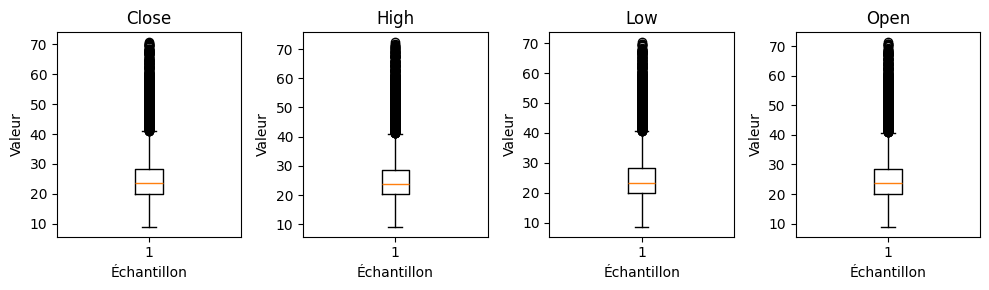

In [ ]:
import matplotlib.pyplot as plt

# Colonnes à tracer
cols = ['Close', 'High', 'Low', 'Open']

# Créer les subplots (1 ligne, 4 colonnes)
fig, axs = plt.subplots(1, len(cols), figsize=(10, 3))

for i, col in enumerate(cols):
    axs[i].boxplot(unique_df[col])
    axs[i].set_title(col)
    axs[i].set_xlabel('Échantillon')
    axs[i].set_ylabel('Valeur')

plt.tight_layout()
plt.show()



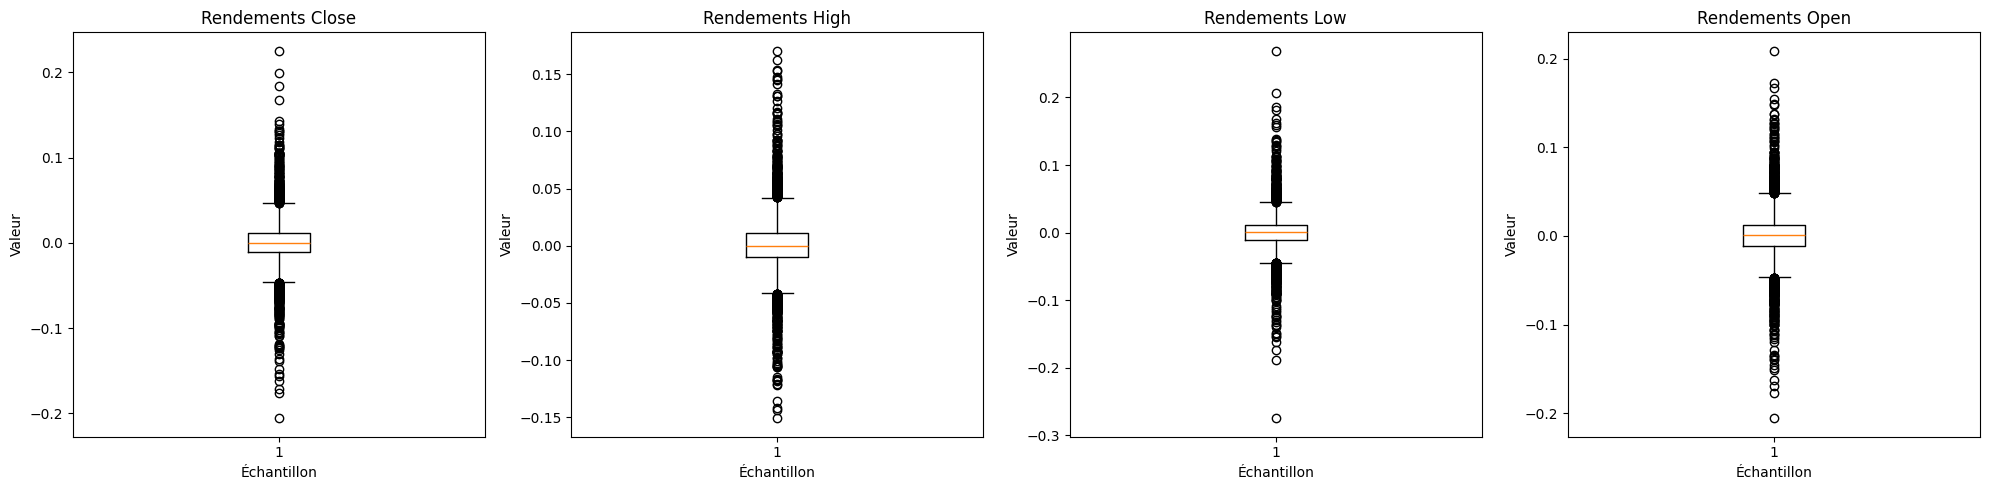

In [ ]:
# Calcul des rendements journaliers (%)
for col in cols:
    unique_df[f'returns_{col}'] = unique_df[col].pct_change()

# Colonnes des rendements
cols_returns = [f'returns_{col}' for col in cols]

# Tracer les boxplots des rendements
fig, axs = plt.subplots(1, len(cols_returns), figsize=(20, 5))

for i, col in enumerate(cols_returns):
    axs[i].boxplot(unique_df[col].dropna())  # dropna() pour éviter les NaN du pct_change
    axs[i].set_title(f'Rendements {col.split("_")[1]}')
    axs[i].set_xlabel('Échantillon')
    axs[i].set_ylabel('Valeur')

plt.tight_layout()
plt.show()


In [ ]:
df = unique_df.drop(['returns_Close', 'returns_High', 'returns_Low', 'returns_Open'], axis=1)
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,17.140852,17.786517,16.948691,17.748082,1078214
2000-01-04,17.063988,17.094733,16.764215,17.063988,2529529
2000-01-05,16.910255,17.063986,16.764213,16.756526,1233422
2000-01-06,16.756529,17.063989,16.718096,16.794961,1221423
2000-01-07,16.756529,16.987125,16.679664,16.679664,866415
...,...,...,...,...,...
2025-09-03,52.820000,53.000000,52.080002,52.500000,2648836
2025-09-04,54.080002,54.299999,52.639999,52.639999,2331733
2025-09-05,53.040001,54.400002,52.820000,54.360001,2111572


# **Exploration des données**

In [ ]:
# Statistiques Descriptives
df.describe()

Price,Close,High,Low,Open,Volume
count,6590.000000,6590.000000,6590.000000,6590.000000,6.590000e+03
mean,26.149557,26.521384,25.776217,26.164099,3.997213e+06
std,11.096614,11.159278,11.026535,11.094872,2.744425e+06
min,8.758259,8.920508,8.363821,8.722917,0.000000e+00
25%,20.077146,20.454226,19.743175,20.128373,2.176016e+06
50%,23.576130,23.939822,23.265623,23.596775,3.417840e+06
75%,28.429224,28.712839,28.097815,28.408309,4.987241e+06
max,70.934227,72.537208,70.531245,71.502886,3.487351e+07


In [ ]:
# Exploration des données
from ydata_profiling import ProfileReport
# Profilage pour GLE
ProfileReport(df, minimal=True, explorative=True).to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 42.22it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

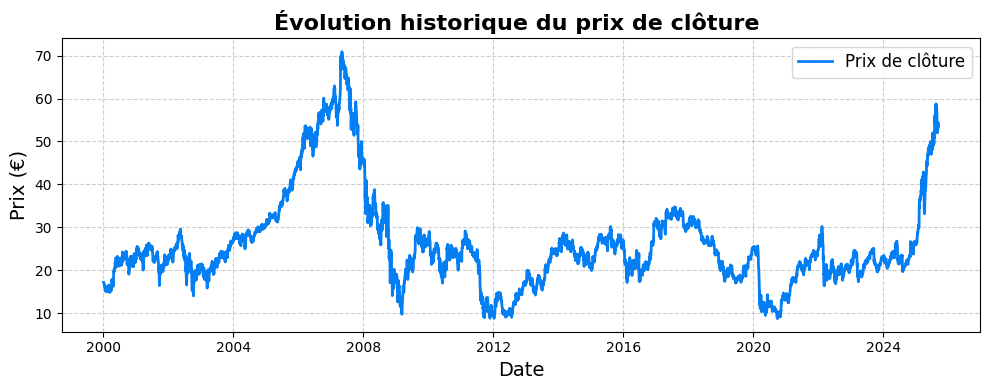

In [ ]:
# Vu historique du Close price
plt.figure(figsize=(10, 4))

plt.plot(df['Close'], color = '#037EF3' , linewidth=2, label='Prix de clôture')

plt.title("Évolution historique du prix de clôture ", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Prix (€)", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=12)
plt.tight_layout()

plt.show()


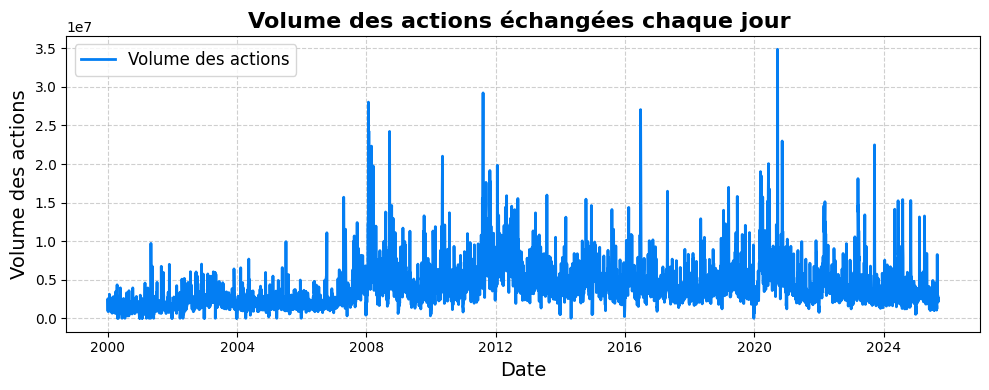

In [ ]:
# Visualisation du volume
# Taille du graphique
plt.figure(figsize=(10, 4))

# Tracé du volume avec une couleur agréable
plt.plot(df['Volume'], color='#037ef3', linewidth=2, label='Volume des actions')

# Titre et labels
plt.title("Volume des actions échangées chaque jour ", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Volume des actions", fontsize=14)

# Grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.6)

# Légende pour identifier le graphique
plt.legend(fontsize=12)

# Ajustement automatique pour éviter les coupures
plt.tight_layout()

# Affichage du graphique
plt.show()

Affichage du volume du 2020-09-09 au 2025-09-09


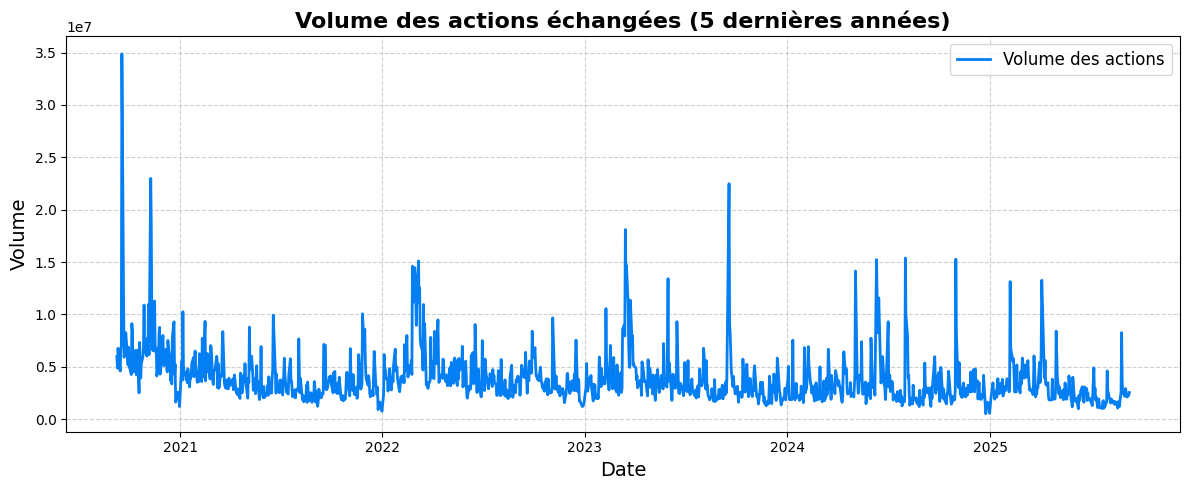

In [ ]:
# Visualisation de l'évolution du volume dans les 5 dernières années
# S'assurer que l'index est bien de type datetime
df = df.copy()
df.index = pd.to_datetime(df.index)

# Calcul de la date limite (5 ans avant la dernière date de la base)
date_limite = df.index.max() - pd.DateOffset(years=5)

# Filtrer les données des 5 dernières années
df_5ans = df[df.index >= date_limite]

# (Optionnel) Afficher la période retenue
print(f"Affichage du volume du {df_5ans.index.min().date()} au {df_5ans.index.max().date()}")

# Création du graphique
plt.figure(figsize=(12, 5))
plt.plot(df_5ans['Volume'], color='#037ef3', linewidth=2, label='Volume des actions')

# Titre et axes
plt.title("Volume des actions échangées (5 dernières années)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Volume", fontsize=14)

# Grille et légende
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Mise en page
plt.tight_layout()

# Affichage
plt.show()

Nous allons procéder à la convertion des données journalières en données annuelles, c'est ce qu'on appelle le resampling temporel.


*   Volume : On utilise la somme ou la moyenne.
*   Close : On utilise la moyenne ou la dernière valeur de l'année.
*   Open : On utilise la moyenne ou la première valeur de l'année.
*   High : Maximum de l'année
*   Low : Minimum de l'année



In [ ]:
# S'assurer que l'index est bien en datetime
df.index = pd.to_datetime(df.index)

# Résumé annuel avec plusieurs agrégations
df_annuel = pd.DataFrame({
    'Volume_total': df['Volume'].resample('Y').sum(),       # Total annuel échangé
    'Volume_moyen': df['Volume'].resample('Y').mean(),      # Volume moyen par jour
    'Close_moyen': df['Close'].resample('Y').mean(),        # Prix moyen de clôture
    'Close_fin_annee': df['Close'].resample('Y').last(),    # Dernier prix de l’année
    'Open_debut_annee': df['Open'].resample('Y').first(),   # Premier prix de l’année
    'High_max': df['High'].resample('Y').max(),             # Plus haut de l’année
    'Low_min': df['Low'].resample('Y').min(),               # Plus bas de l’année
})


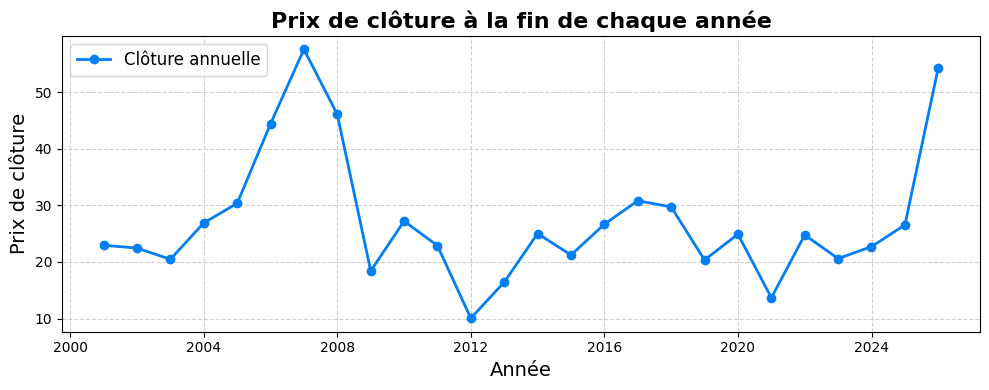

In [ ]:
#Evolution du prix de clôture annuelle
import matplotlib.pyplot as plt
import pandas as pd

# S'assurer que l'index est datetime
df.index = pd.to_datetime(df.index)

# Calcul du prix de clôture à la fin de chaque année
close_annuel = df['Close'].resample('Y').last()

# Création du graphique
plt.figure(figsize=(10, 4))  # Taille du graphique

# Tracé de la courbe avec style
plt.plot(close_annuel.index, close_annuel.values,
         color='#037ef3', linewidth=2, marker='o', label='Clôture annuelle')

# Titre et labels avec personnalisation
plt.title("Prix de clôture à la fin de chaque année", fontsize=16, fontweight='bold')
plt.xlabel("Année", fontsize=14)
plt.ylabel("Prix de clôture", fontsize=14)

# Grille stylisée
plt.grid(True, linestyle='--', alpha=0.6)

# Légende
plt.legend(fontsize=12)

# Mise en page automatique
plt.tight_layout()

# Affichage du graphique
plt.show()


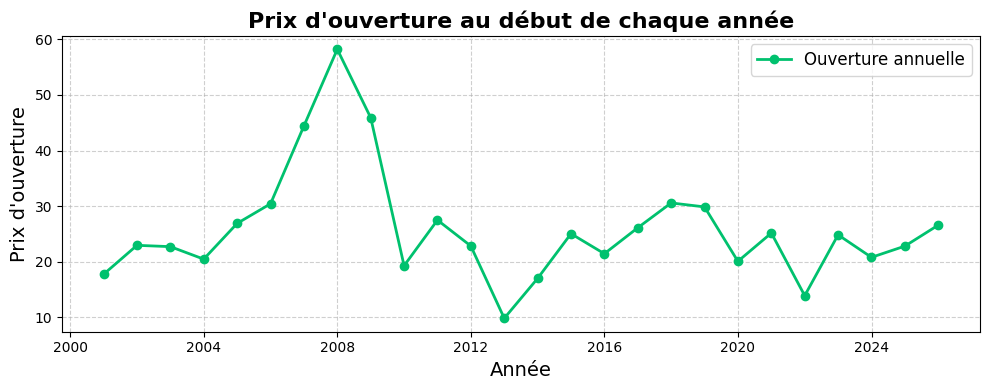

In [ ]:
# Evolution du prix d'ouverture annuelle
open_annuel = df['Open'].resample('Y').first()

plt.figure(figsize=(10, 4))
plt.plot(open_annuel.index, open_annuel.values,
         color='#00c16e', linewidth=2, marker='o', label='Ouverture annuelle')

plt.title("Prix d'ouverture au début de chaque année", fontsize=16, fontweight='bold')
plt.xlabel("Année", fontsize=14)
plt.ylabel("Prix d'ouverture", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


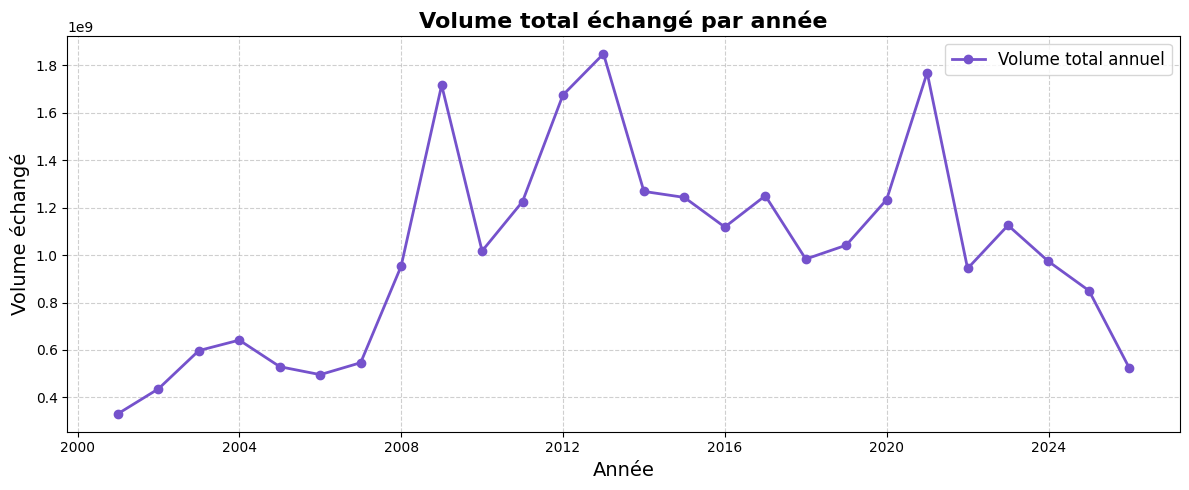

In [ ]:
# Evolution du volume annuel
volume_total_annuel = df['Volume'].resample('Y').sum()

plt.figure(figsize=(12, 5))
plt.plot(volume_total_annuel.index, volume_total_annuel.values,
         color='#7552cc', linewidth=2, marker='o', label='Volume total annuel')

plt.title("Volume total échangé par année", fontsize=16, fontweight='bold')
plt.xlabel("Année", fontsize=14)
plt.ylabel("Volume échangé", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


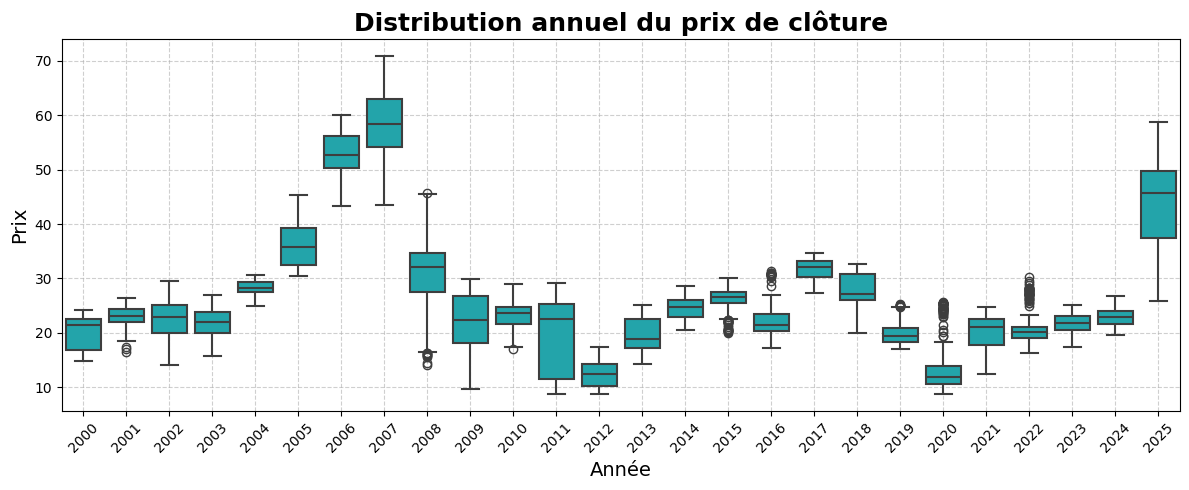

In [ ]:
import seaborn as sns
# Create a 'Year' column from the index
df['Year'] = df.index.year

# Set plot style (similar to your image)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Year', y='Close', color='#0cb9c1', linewidth=1.5)

# Customization
plt.title("Distribution annuel du prix de clôture", fontsize=18, fontweight='bold')
plt.xlabel("Année", fontsize=14)
plt.ylabel("Prix", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Clean layout
plt.tight_layout()
plt.show()


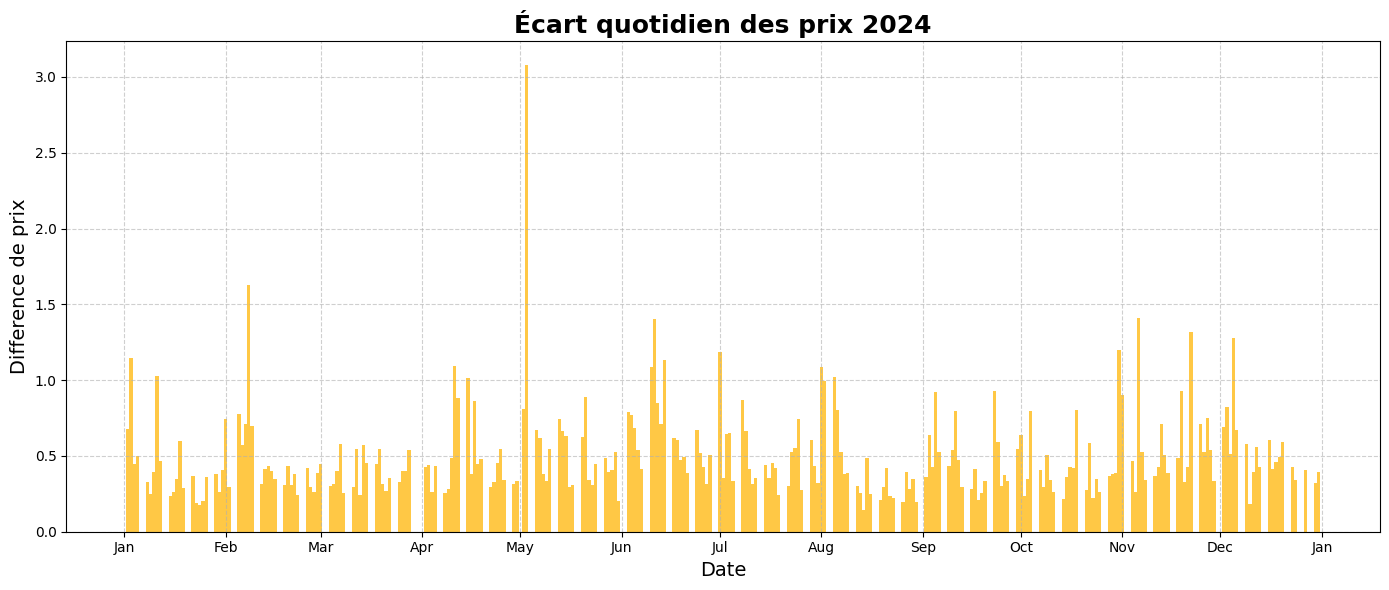

In [ ]:

# Step 1: Ensure datetime index
df.index = pd.to_datetime(df.index)

# Step 2: Choose the year (e.g. 2024)
year = 2024
df_year = df[df.index.year == year]

# Step 3: Calculate daily price range (High - Low)
df_year['Daily_Range'] = df_year['High'] - df_year['Low']

# Step 4: Plot
plt.figure(figsize=(14, 6))
plt.bar(df_year.index, df_year['Daily_Range'], color='#ffc845', width=1.0)

# Customization
plt.title(f"Écart quotidien des prix {year}", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Difference de prix", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Optional: Better date formatting (month names)
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.show()


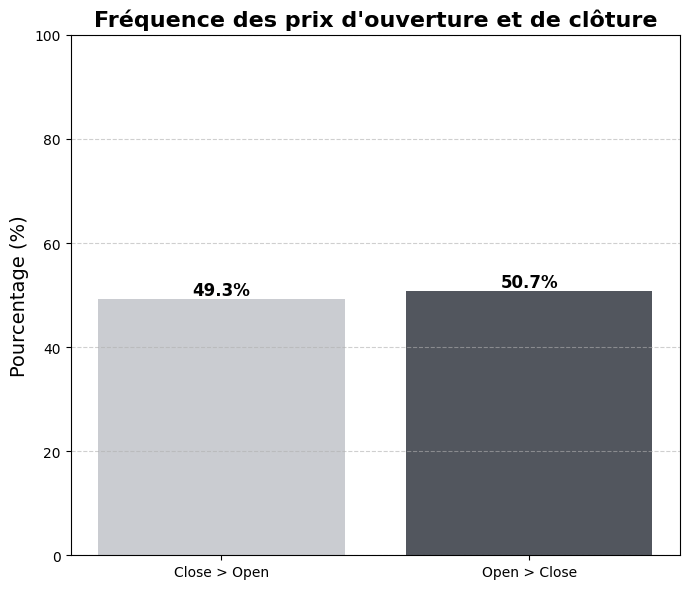

In [ ]:
import matplotlib.pyplot as plt

# Calcul des conditions
close_greater = (df['Close'] > df['Open']).sum()
open_greater = (df['Open'] > df['Close']).sum()

# Calcul des pourcentages
total = close_greater + open_greater
close_percent = close_greater / total * 100
open_percent = open_greater / total * 100

# Données pour le graphique
labels = ['Close > Open', 'Open > Close']
values = [close_percent, open_percent]
colors = ['#caccd1', '#52565e']  # Vert olive et rouge foncé

# Création du graphique
plt.figure(figsize=(7, 6))
bars = plt.bar(labels, values, color=colors)

# Affichage des valeurs en % au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Personnalisation du titre et axes
plt.title('Fréquence des prix d\'ouverture et de clôture', fontsize=16, fontweight='bold')
plt.ylabel('Pourcentage (%)', fontsize=14)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


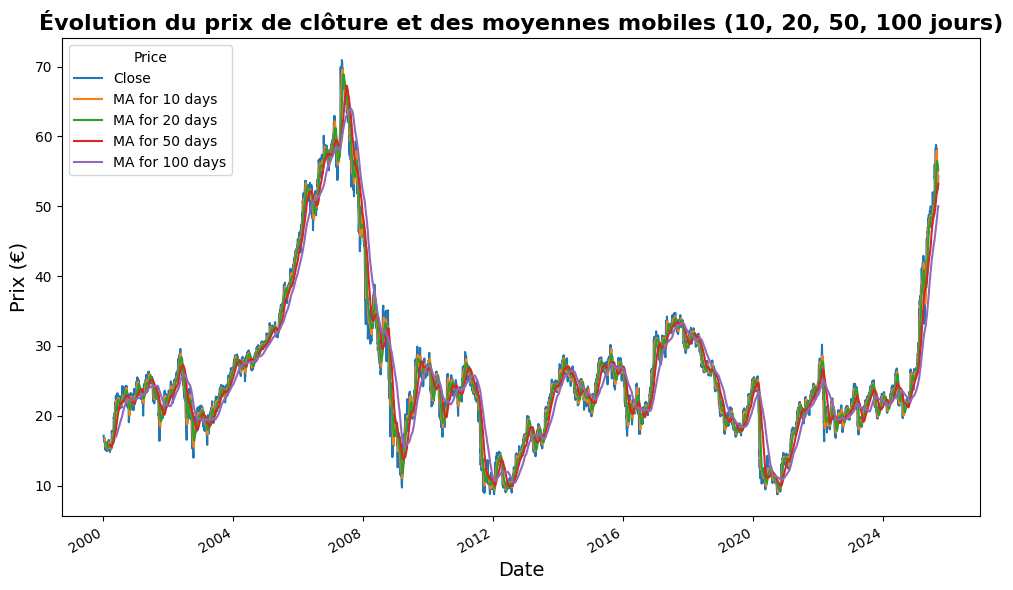

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Exemple de périodes pour les moyennes mobiles
MA_days = [10, 20, 50, 100, 200]
df2 = df.copy()

# Calcul des moyennes mobiles et ajout dans le DataFrame df_GLE
for ma in MA_days:
    column_name = f'MA for {ma} days'
    df2[column_name] = df2['Close'].rolling(window=ma).mean()

# Tracer la colonne Close et les moyennes mobiles

df2[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days', 'MA for 100 days']].plot(subplots=False, figsize=(10, 6))

# Ajouter un titre et des labels
plt.title("Évolution du prix de clôture et des moyennes mobiles (10, 20, 50, 100 jours)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Prix (€)", fontsize=14)

# Afficher le graphique
plt.tight_layout()
plt.show()


In [ ]:
# 1. Remettre 'Date' comme colonne (si c'est l'index)
df_reset = df.reset_index()

# 2. Garder uniquement les colonnes utiles (sans les colonnes 'MA for X days')
colonnes_a_garder = [col for col in df_reset.columns if 'MA' not in col and col in ['Date', 'Open', 'Close', 'High', 'Low', 'Volume']]

# 3. Créer un DataFrame nettoyé
df_clean = df_reset[colonnes_a_garder].copy()

# 4. Remettre 'Date' comme index si tu veux refaire des graphiques temporels
df_clean.set_index('Date', inplace=True)
df_clean

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,17.140852,17.786517,16.948691,17.748082,1078214
2000-01-04,17.063988,17.094733,16.764215,17.063988,2529529
2000-01-05,16.910255,17.063986,16.764213,16.756526,1233422
2000-01-06,16.756529,17.063989,16.718096,16.794961,1221423
2000-01-07,16.756529,16.987125,16.679664,16.679664,866415
...,...,...,...,...,...
2025-09-03,52.820000,53.000000,52.080002,52.500000,2648836
2025-09-04,54.080002,54.299999,52.639999,52.639999,2331733
2025-09-05,53.040001,54.400002,52.820000,54.360001,2111572


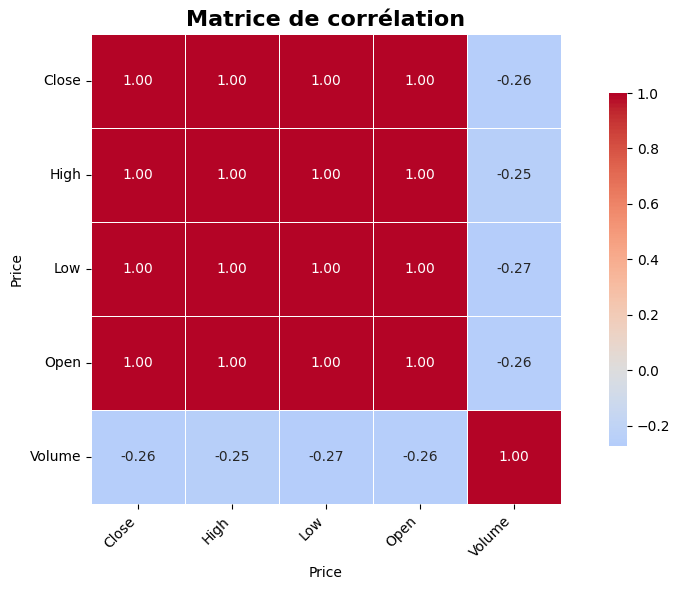

In [ ]:
#Analyse de la corrélation entre les variables
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Compute the correlation matrix
correlation_matrix = df_clean.corr()

# 2. Display the correlation matrix as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', square=True, cbar_kws={"shrink": .75})

# 3. Customize the plot
plt.title("Matrice de corrélation", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


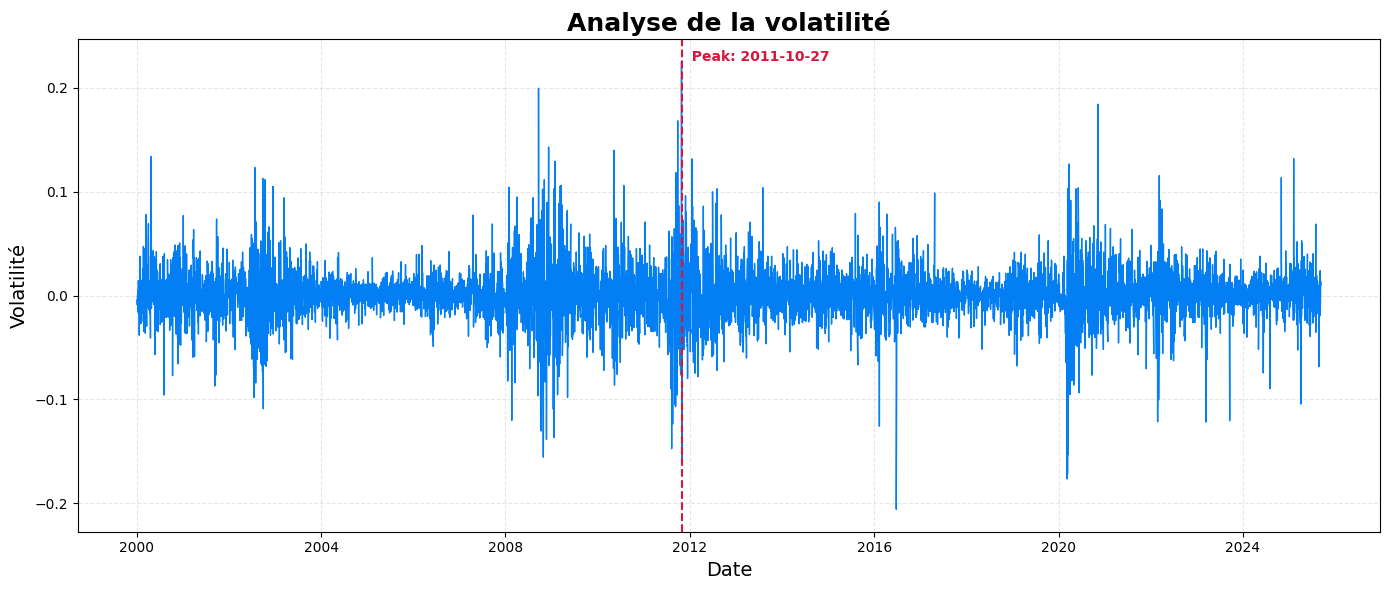

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Vérifie si l'index est déjà en datetime
if not pd.api.types.is_datetime64_any_dtype(df_clean.index):
    df_clean.index = pd.to_datetime(df_clean.index)

# Calcul de la volatilité : variation relative journalière du prix de clôture
df_clean['Volatility'] = df_clean['Close'].pct_change()

# Trouver la date de volatilité maximale (en valeur absolue)
max_volatility_date = df_clean['Volatility'].abs().idxmax()
max_volatility_value = df_clean.loc[max_volatility_date, 'Volatility']

# Tracer l’évolution de la volatilité
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Volatility'], color='#037ef3', linewidth=1)

# Marquer le pic de volatilité
plt.axvline(x=max_volatility_date, color='crimson', linestyle='--', linewidth=1.5)
plt.text(max_volatility_date, max_volatility_value,
         f'  Peak: {max_volatility_date.date()}',
         color='crimson', fontsize=10, fontweight='bold')

#  Mise en forme du graphique
plt.title("Analyse de la volatilité", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Volatilité", fontsize=14)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



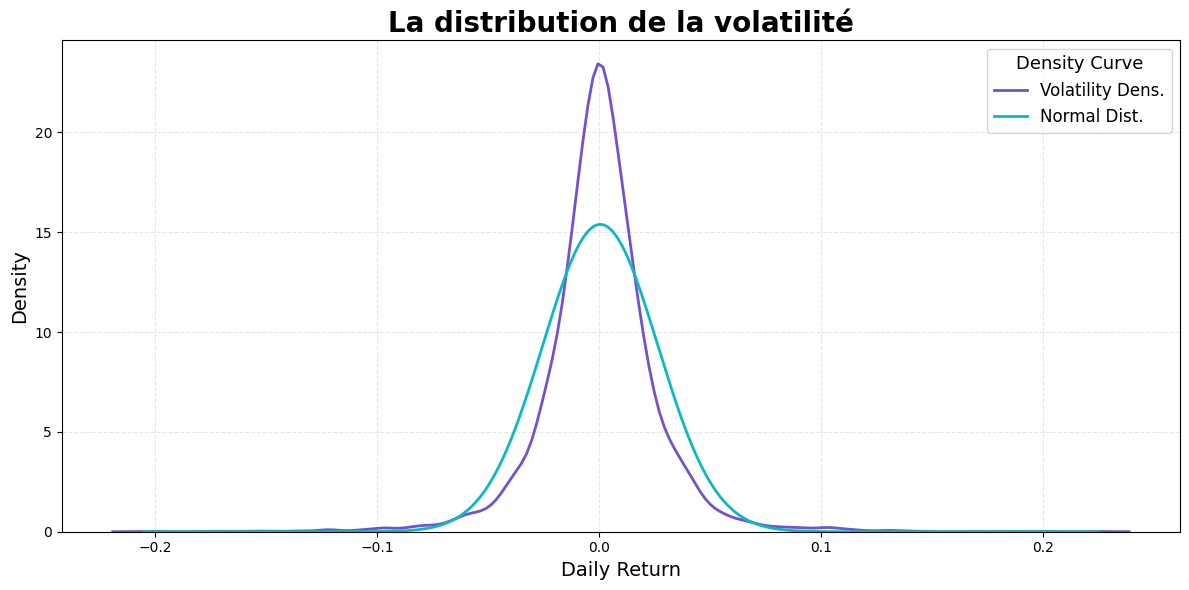

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Vérifie que l'index est bien datetime
if not pd.api.types.is_datetime64_any_dtype(df_clean.index):
    df_clean.index = pd.to_datetime(df_clean.index)

# Calcul de la volatilité journalière (retour)
df_clean['Volatility'] = df_clean['Close'].pct_change()

# Nettoyage : supprimer les valeurs nulles ou infinies
volatility = df_clean['Volatility'].dropna()

# Paramètres de la distribution normale (même moyenne et écart-type)
mu, std = volatility.mean(), volatility.std()
x = np.linspace(volatility.min(), volatility.max(), 1000)
normal_pdf = norm.pdf(x, mu, std)

# Tracer la densité de la volatilité et la courbe normale
plt.figure(figsize=(12, 6))
sns.kdeplot(volatility, color='#7552cc', label='Volatility Dens.', linewidth=2)
plt.plot(x, normal_pdf, color='#0cb9c1', label='Normal Dist.', linewidth=2)

# Mise en forme
plt.title("La distribution de la volatilité", fontsize=20, fontweight='bold')
plt.xlabel("Daily Return", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(title="Density Curve", fontsize=12, title_fontsize=13, frameon=True)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


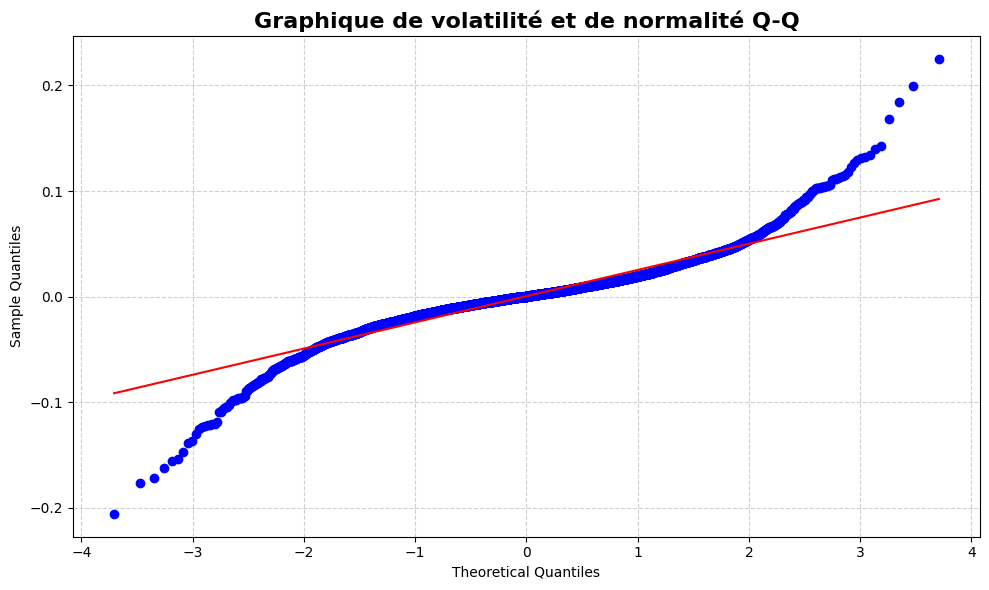

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Vérifie que l'index est bien datetime
if not pd.api.types.is_datetime64_any_dtype(df_clean.index):
    df_clean.index = pd.to_datetime(df_clean.index)

# Calcul de la volatilité journalière (retour)
df_clean['Volatility'] = df_clean['Close'].pct_change()

# Nettoyer les NaN
volatility = df_clean['Volatility'].dropna()

# Tracer Q-Q plot pour comparer à la distribution normale
plt.figure(figsize=(10, 6))
stats.probplot(volatility, dist="norm", plot=plt)

plt.title("Graphique de volatilité et de normalité Q-Q", fontsize=16, fontweight='bold')
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



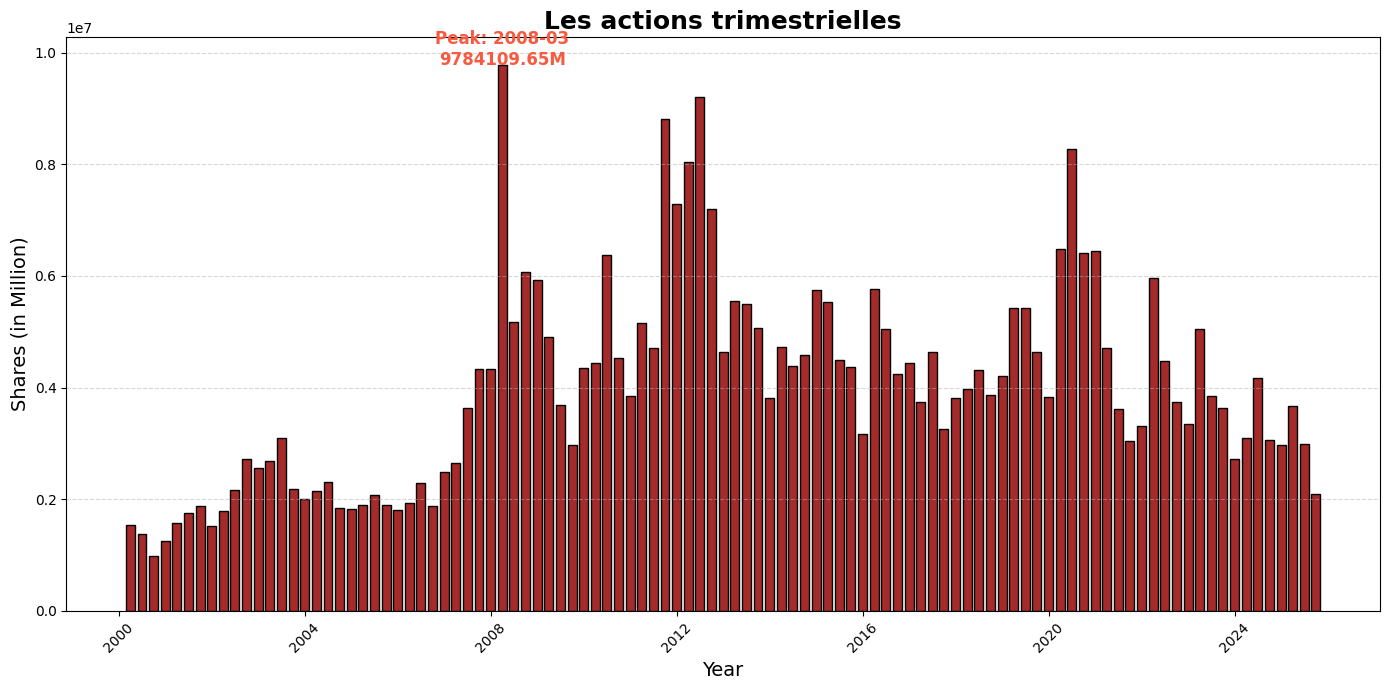

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Grouper par trimestre et sommer/faire la moyenne selon le contexte
# Ici on suppose que la colonne est déjà trimestrielle, sinon on peut resampler
df_quarterly = df_clean.resample('Q').mean()  # ou sum() selon les données

# Trouver la date du pic et la valeur max
peak_date = df_quarterly['Volume'].idxmax()
peak_value = df_quarterly['Volume'].max()

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(df_quarterly.index, df_quarterly['Volume'], width=70, color='brown', edgecolor='black')

# Mettre en évidence la barre du pic (avec une couleur différente)
for bar in bars:
    if bar.get_x() == peak_date.to_pydatetime():
        bar.set_color('#f85a40')
# Ajouter texte pour la date du pic
plt.text(peak_date, peak_value + 0.1, f'Peak: {peak_date.strftime("%Y-%m")}\n{peak_value:.2f}M',
         color='#f85a40', fontsize=12, fontweight='bold', ha='center')

# Titres et labels
plt.title("Les actions trimestrielles", fontsize=18, fontweight='bold')
plt.ylabel("Shares (in Million)", fontsize=14)
plt.xlabel("Year", fontsize=14)

# Amélioration de l'affichage des dates
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# **EMA Prediction**

In [ ]:
# Assurons-nous d'utiliser les colonnes High et Low de ton DataFrame df
high_prices = df_clean['High'].values    # convertit en array numpy
low_prices = df_clean['Low'].values      # convertit en array numpy

# Calcul du prix moyen (mid price)
mid_prices = (high_prices + low_prices) / 2.0

# Vérification
print(mid_prices[:10])  # affiche les 10 premiers prix moyens


[17.36760393 16.92947368 16.91409985 16.89104292 16.83339432 16.90257282
 16.73731331 16.61816751 16.4336986  16.52593736]


In [ ]:
train_data = mid_prices[:11000]
test_data = mid_prices[11000:]


In [ ]:
iscaler = MinMaxScaler()
train_data = train_data.reshape(-1,1)
test_data = test_data.reshape(-1,1)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Extract Close prices as NumPy array
data = df_clean[['Close']].values  # shape: (6590, 1)

# Train/test split (e.g., 80% for training)
split_index = int(len(data) * 0.8)  # ~5272 for training
train_data = data[:split_index]
test_data = data[split_index:]

# Define scaler and window size
scaler = MinMaxScaler()
smoothing_window_size = 2500

# Normalize training data in chunks
for i in range(0, len(train_data) - smoothing_window_size, smoothing_window_size):
    scaler.fit(train_data[i:i + smoothing_window_size])
    train_data[i:i + smoothing_window_size] = scaler.transform(train_data[i:i + smoothing_window_size])

# Normalize the remaining portion (last window)
scaler.fit(train_data[i + smoothing_window_size:])
train_data[i + smoothing_window_size:] = scaler.transform(train_data[i + smoothing_window_size:])

# Normalize test data with last trained scaler
test_data = scaler.transform(test_data)


In [ ]:
# Reshape both train and test data
train_data = train_data.reshape(-1)

# Normalize test data
test_data = scaler.transform(test_data).reshape(-1)

In [ ]:
import numpy as np

# Smooth only the training data using Exponential Moving Average
EMA = np.zeros_like(train_data)
gamma = 0.1  # Smoothing factor (adjust if needed)

# Initialize EMA with the first training value
EMA[0] = train_data[0]

# Apply EMA smoothing
for t in range(1, len(train_data)):
    EMA[t] = gamma * train_data[t] + (1 - gamma) * EMA[t - 1]

# Replace train_data with the smoothed version
train_data = EMA

# Combine smoothed train and normalized test for future use (visualization or model input)
all_data = np.concatenate([train_data, test_data], axis=0)


MSE error for standard averaging: 0.01175


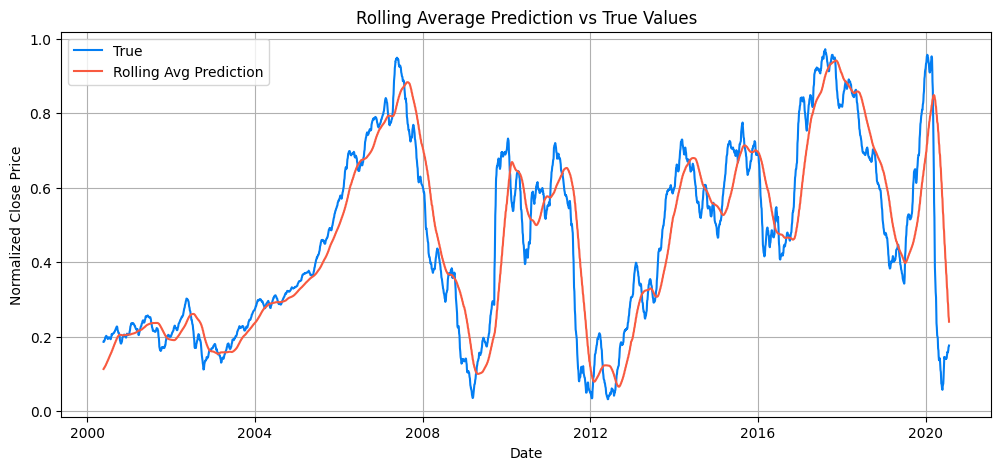

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

window_size = 100
N = train_data.shape[0]  # Total number of training points
std_avg_predictions = []
std_avg_dates = []
mse_errors = []

# Loop through each point after the initial window
for pred_idx in range(window_size, N):
    # Predict the next value as the average of the last `window_size` values
    window_avg = np.mean(train_data[pred_idx - window_size: pred_idx])
    std_avg_predictions.append(window_avg)

    # True value at this point
    true_value = train_data[pred_idx]
    mse_errors.append((window_avg - true_value) ** 2)

    # Get corresponding date for x-axis (from original df)
    date = df.index[pred_idx]
    std_avg_dates.append(date)

# Final MSE
mse = np.mean(mse_errors)
print(f'MSE error for standard averaging: {mse:.5f}')

# Optional: plot prediction vs actual
plt.figure(figsize=(12, 5))
plt.plot(std_avg_dates, train_data[window_size:], label='True', color='#037ef3')
plt.plot(std_avg_dates, std_avg_predictions, label='Rolling Avg Prediction', color='#f85a40')
plt.title('Rolling Average Prediction vs True Values')
plt.xlabel('Date')
plt.ylabel('Normalized Close Price')
plt.legend()
plt.grid()


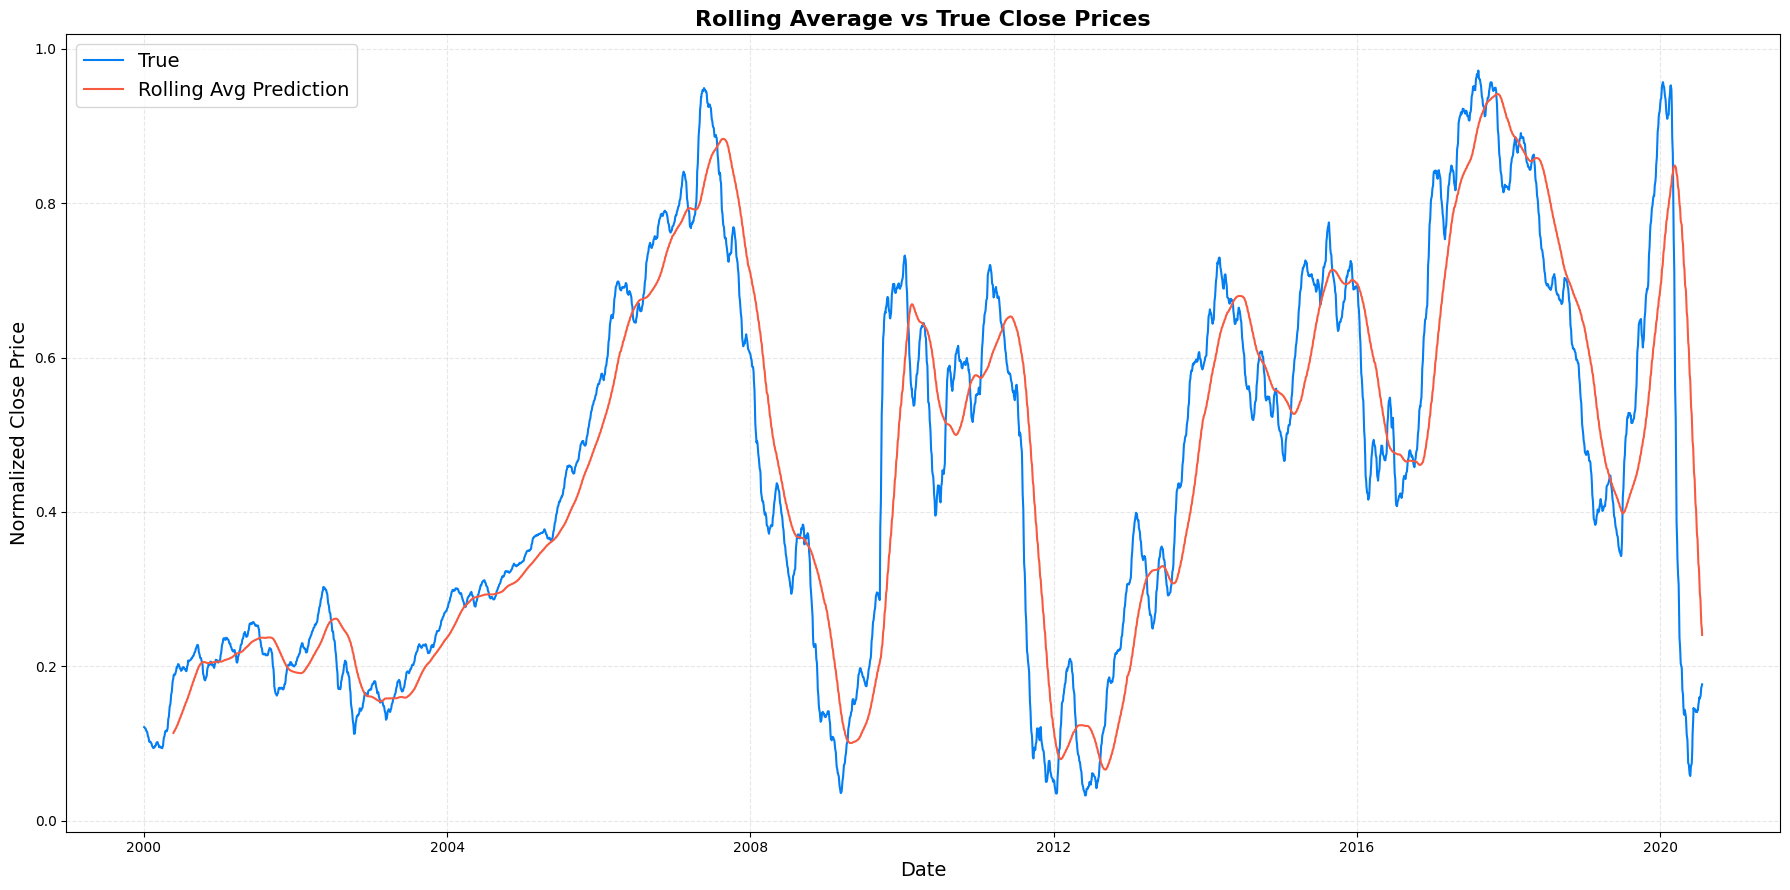

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

# Plot full true data (blue)
plt.plot(df.index[:len(train_data)], train_data, color='#037ef3', label='True')

# Plot rolling average predictions (orange)
plt.plot(std_avg_dates, std_avg_predictions, color='#f85a40', label='Rolling Avg Prediction')

# Labels and legend
plt.xlabel('Date', fontsize=14)
plt.ylabel('Normalized Close Price', fontsize=14)
plt.title('Rolling Average vs True Close Prices', fontsize=16, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import datetime as dt

# Parameters
window_size = 100
N = train_data.shape[0]  # Number of training points

run_avg_predictions = []
run_avg_dates = []
mse_errors = []

running_mean = train_data[0]  # Initialize with the first value
run_avg_predictions.append(running_mean)
run_avg_dates.append(df.index[0])  # First date

decay = 0.5  # EMA decay factor

# Compute EMA-based predictions
for pred_idx in range(1, N):
    # EMA update
    running_mean = running_mean * decay + (1.0 - decay) * train_data[pred_idx - 1]
    run_avg_predictions.append(running_mean)

    # Error
    mse_errors.append((run_avg_predictions[-1] - train_data[pred_idx])**2)

    # Date for plotting
    run_avg_dates.append(df.index[pred_idx])

# Print MSE
print('MSE error for EMA averaging: %.5f' % (0.5 * np.mean(mse_errors)))


MSE error for EMA averaging: 0.00004


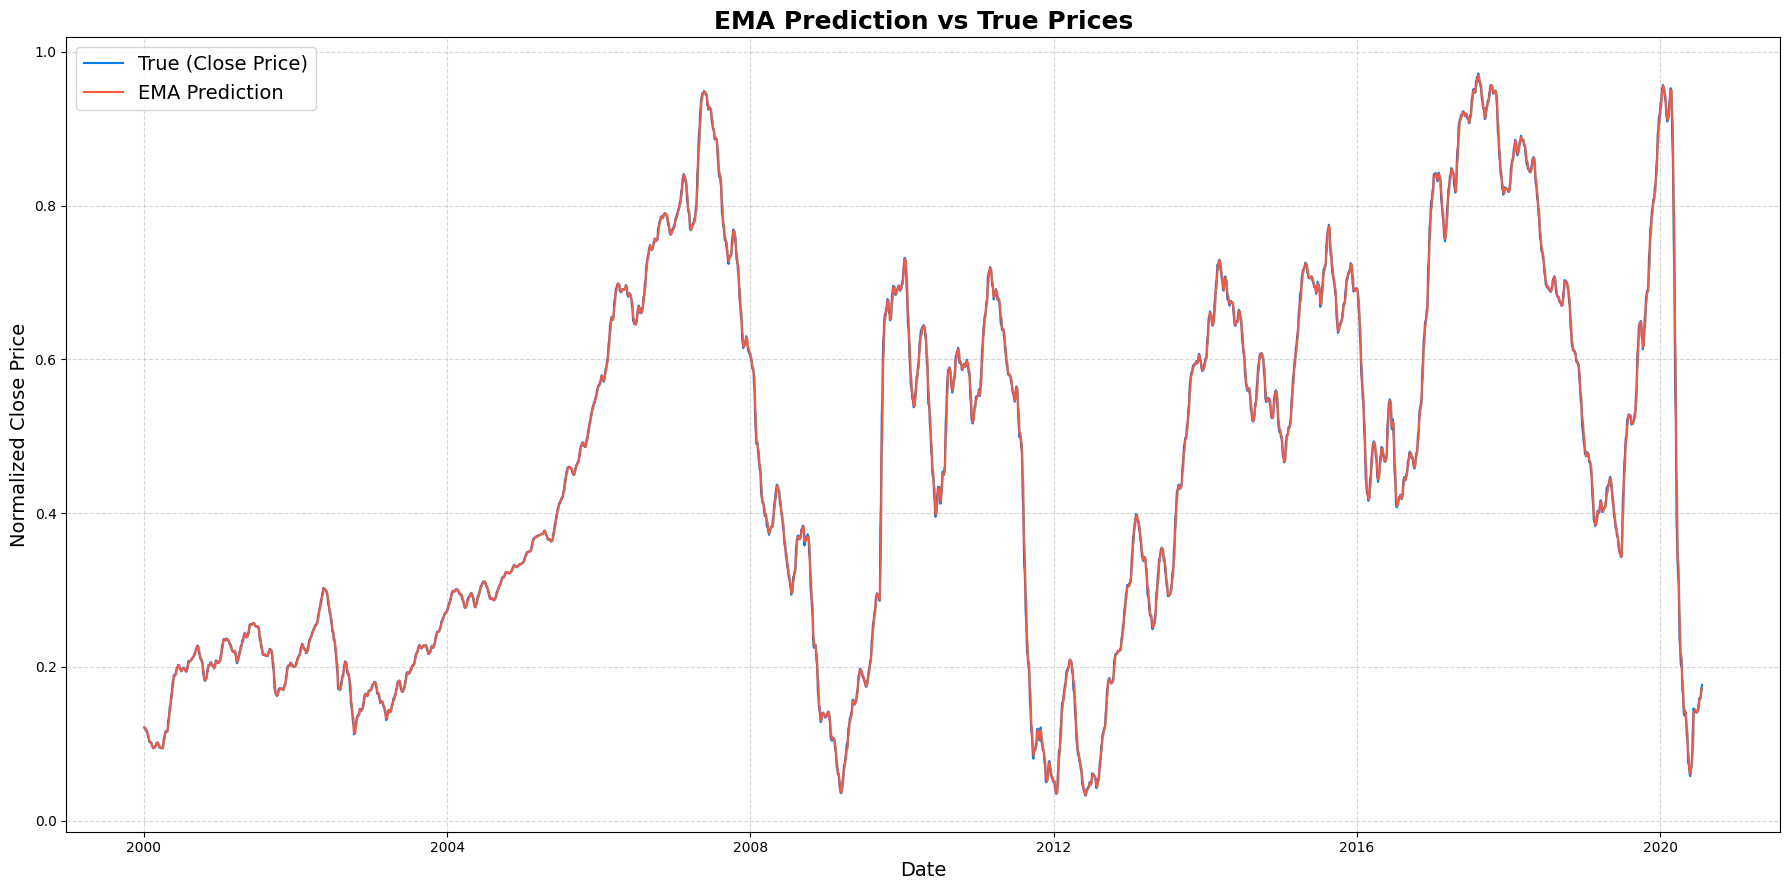

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

# Plot true (normalized) close prices
plt.plot(df.index[:N], train_data, color='#037ef3', label='True (Close Price)')

# Plot EMA-based predictions
plt.plot(df.index[:N], run_avg_predictions, color='#f85a40', label='EMA Prediction')

# Labels and formatting
plt.title("EMA Prediction vs True Prices", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Normalized Close Price", fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
